In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import mysql.connector

db=mysql.connector.connect(host="localhost",username="root",password="Ph2#Dr5$",database="ecommerce")
cur=db.cursor()

# List all unique cities where customers are located.

In [8]:
query="""select distinct customer_city from olist_customers_dataset"""
cur.execute(query)
data=cur.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',),
 ('rio de janeiro',),
 ('lencois paulista',),
 ('caxias do sul',),
 ('piracicaba',),
 ('guarulhos',),
 ('pacaja',),
 ('florianopolis',),
 ('aparecida de goiania',),
 ('santo andre',),
 ('goiania',),
 ('cachoeiro de itapemirim',),
 ('sao jose dos campos',),
 ('sao roque',),
 ('camacari',),
 ('resende',),
 ('sumare',),
 ('novo hamburgo',),
 ('sao luis',),
 ('sao jose',),
 ('santa barbara',),
 ('ribeirao preto',),
 ('ituiutaba',),
 ('taquarituba',),
 ('sao jose dos pinhais',),
 ('barrinha',),
 ('parati',),
 ('dourados',),
 ('trindade',),
 ('cascavel',),
 ('fortaleza',),
 ('brasilia',),
 ('pelotas',),
 ('porto alegre',),
 ('salto',),
 ('jundiai',),
 ('cacapava',),
 ('sao vicente',),
 ('uberlandia',),
 ('botelhos',),
 ('sao goncalo',),
 ('araucaria',),
 ('nova iguacu',),
 ('areia branca',),
 ('campo

# Count the number of orders placed in 2017.

In [10]:
query="""select count(order_id) from olist_orders_dataset where year(order_purchase_timestamp)=2017"""
cur.execute(query)
data=cur.fetchall()
data[0][0]

45101

# Find the total sales per category.

In [22]:
query="""select upper(olist_products_dataset.product_category_name) as category,round(sum(olist_order_payments_dataset.payment_value),2) as sales from olist_products_dataset
inner join olist_order_items_dataset
on olist_products_dataset.product_id=olist_order_items_dataset.product_id
inner join olist_order_payments_dataset
on olist_order_payments_dataset.order_id= olist_order_items_dataset.order_id
group by category
"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Category","Sales"])
print(a)

                         Category       Sales
0                      PERFUMARIA   506738.66
1                MOVEIS_DECORACAO  1430176.39
2                       TELEFONIA   486882.05
3     FASHION_BOLSAS_E_ACESSORIOS   218158.28
4                 CAMA_MESA_BANHO  1712553.67
..                            ...         ...
69              CDS_DVDS_MUSICAIS     1199.43
70                     LA_CUISINE     2913.53
71  FASHION_ROUPA_INFANTO_JUVENIL      785.67
72                       PC_GAMER     2174.43
73             SEGUROS_E_SERVICOS      324.51

[74 rows x 2 columns]


# Calculate the percentage of orders that were paid in installments.

In [30]:
query="""select (sum(case when payment_installments>=1 then 1 else 0 end))/count(*)*100 from olist_order_payments_dataset"""
cur.execute(query)
data=cur.fetchall()
data[0][0]

Decimal('99.9981')

# Count the number of customers from each state. 


   State  Count of customers
0     SP              404268
1     RN                5041
2     AC                1301
3     RJ              121169
4     ES               16748
5     MG              126336
6     BA               36045
7     SE                3563
8     PE               16432
9     AL                4183
10    PB                5538
11    CE               11674
12    PI                4549
13    MA                7853
14    PA               10853
15    AP                 853
16    AM                2432
17    RR                 646
18    DF               12986
19    GO               20139
20    RO                3478
21    TO                3576
22    MT               12031
23    MS               10431
24    RS               61851
25    PR               57859
26    SC               38328


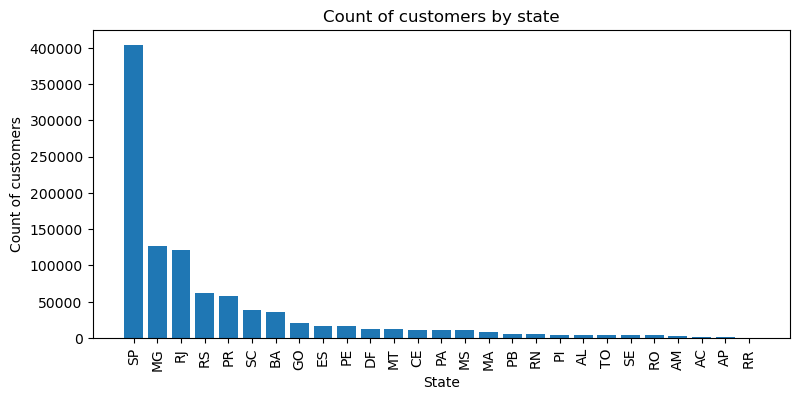

In [46]:
query="""select geolocation_state,count(geolocation_zip_code_prefix) from olist_geolocation_dataset group by  geolocation_state"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["State","Count of customers"])
print(a)
a=a.sort_values(by="Count of customers",ascending=False)
plt.figure(figsize=(9,4))
plt.bar(a["State"],a["Count of customers"])
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Count of customers")
plt.title("Count of customers by state")
plt.show()

# Calculate the number of orders per month in 2018.

       Month  Count of orders
0       July             6292
1     August             6512
2   February             6728
3       June             6167
4      March             7211
5    January             7269
6        May             6873
7      April             6939
8  September               16
9    October                4


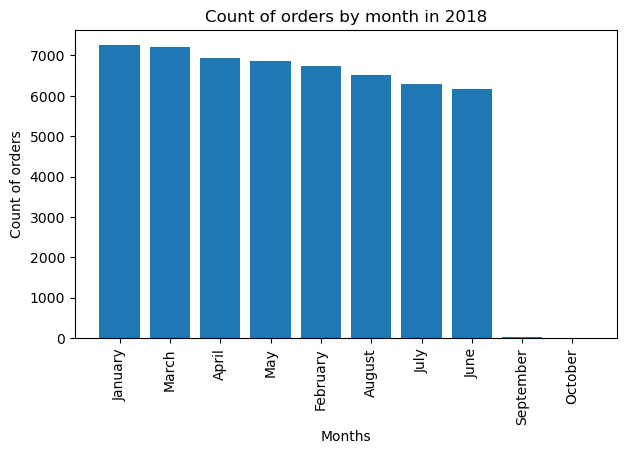

In [47]:
query="""select monthname(order_purchase_timestamp)as month,count(order_id) as count_of_orders from olist_orders_dataset
where year(order_purchase_timestamp)=2018 group by month """
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Month","Count of orders"])
print(a)
a=a.sort_values(by="Count of orders",ascending=False)
plt.figure(figsize=(7,4))
plt.bar(a["Month"],a["Count of orders"])
plt.xticks(rotation=90)
plt.xlabel("Months")
plt.ylabel("Count of orders")
plt.title("Count of orders by month in 2018")
plt.show()

#  Find the average number of products per order, grouped by customer city.

In [50]:
query="""with count_per_order as
(select olist_orders_dataset.order_id,olist_orders_dataset.customer_id,count(olist_order_items_dataset.order_id) as oc
from ecommerce.olist_orders_dataset inner join ecommerce.olist_order_items_dataset
on olist_orders_dataset.order_id=olist_order_items_dataset.order_id
group by olist_orders_dataset.order_id,olist_orders_dataset.customer_id)

select olist_customers_dataset.customer_city,round(avg(count_per_order.oc),2)
from ecommerce.olist_customers_dataset inner join count_per_order
on olist_customers_dataset.customer_id=count_per_order.customer_id
group by olist_customers_dataset.customer_city; """
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["City","Count of products per order"])
print(a)

                      City Count of products per order
0                sao paulo                        1.16
1      sao jose dos campos                        1.14
2             porto alegre                        1.17
3                  indaial                        1.12
4             treze tilias                        1.27
...                    ...                         ...
4105            japaratuba                        1.00
4106        sebastiao leal                        1.00
4107                buriti                        3.00
4108  morro agudo de goias                        1.00
4109         padre paraiso                        1.00

[4110 rows x 2 columns]


# Calculate the percentage of total revenue contributed by each product category.

In [52]:
query="""select upper(olist_products_dataset.product_category_name) as category,round((sum(olist_order_payments_dataset.payment_value)/(select sum(payment_value) from olist_order_payments_dataset)),2)*100 as sales from olist_products_dataset
inner join olist_order_items_dataset
on olist_products_dataset.product_id=olist_order_items_dataset.product_id
inner join olist_order_payments_dataset
on olist_order_payments_dataset.order_id= olist_order_items_dataset.order_id
group by category
"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Category","Revenue%"])
print(a)

                         Category  Revenue%
0                      PERFUMARIA       3.0
1                MOVEIS_DECORACAO       9.0
2                       TELEFONIA       3.0
3     FASHION_BOLSAS_E_ACESSORIOS       1.0
4                 CAMA_MESA_BANHO      11.0
..                            ...       ...
69              CDS_DVDS_MUSICAIS       0.0
70                     LA_CUISINE       0.0
71  FASHION_ROUPA_INFANTO_JUVENIL       0.0
72                       PC_GAMER       0.0
73             SEGUROS_E_SERVICOS       0.0

[74 rows x 2 columns]


# Identify the correlation between product price and the number of times a product has been purchased.

In [57]:
query="""select olist_products_dataset.product_category_name,count(olist_products_dataset.product_id),round(avg(olist_order_items_dataset.price),2)
from ecommerce.olist_products_dataset inner join ecommerce.olist_order_items_dataset
on olist_products_dataset.product_id=olist_order_items_dataset.product_id
group by olist_products_dataset.product_category_name;
"""

cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Category Name","Count of product","Price"])
print(a)
np.corrcoef(a["Count of product"],a["Price"])

                                    Category Name  Count of product   Price
0                                    beleza_saude              9670  130.16
1                                   esporte_lazer              8641  114.34
2                                      cool_stuff              3796  167.36
3                          informatica_acessorios              7827  116.51
4                              relogios_presentes              5991  201.14
..                                            ...               ...     ...
69                                         flores                33   33.64
70  portateis_cozinha_e_preparadores_de_alimentos                15  264.57
71                                casa_conforto_2                30   25.34
72                      moveis_colchao_e_estofado                38  114.95
73                              cds_dvds_musicais                14   52.14

[74 rows x 3 columns]


array([[ 1.        , -0.10631514],
       [-0.10631514,  1.        ]])

# Calculate the total revenue generated by each seller, and rank them by revenue.

                          Seller_id    Revenue  Rank
0  7c67e1448b00f6e969d365cea6b010ab  507166.91     1
1  1025f0e2d44d7041d6cf58b6550e0bfa  308222.04     2
2  4a3ca9315b744ce9f8e9374361493884  301245.27     3
3  1f50f920176fa81dab994f9023523100  290253.42     4
4  53243585a1d6dc2643021fd1853d8905  284903.08     5


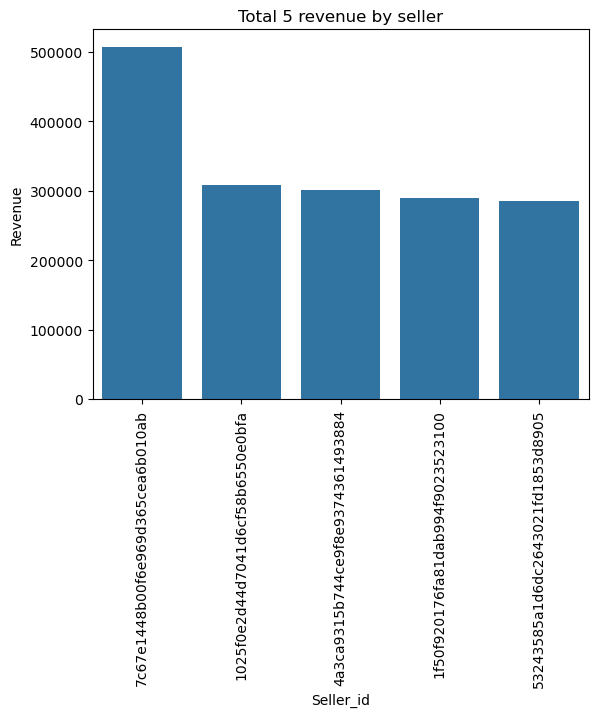

In [81]:
query="""select *, dense_rank() over(order by revenue desc) as rn from
(select olist_order_items_dataset.seller_id,round(sum(olist_order_payments_dataset.payment_value),2) as revenue
from ecommerce.olist_order_items_dataset inner join ecommerce.olist_order_payments_dataset
on olist_order_items_dataset.order_id=olist_order_payments_dataset.order_id
group by olist_order_items_dataset.seller_id) as a"""

cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Seller_id","Revenue","Rank"])
b=a.head()
print(b)
sns.barplot(data=b,x="Seller_id",y="Revenue")
plt.xticks(rotation=90)
plt.title("Total 5 revenue by seller")
plt.show()

# Calculate the moving average of order values for each customer over their order history.

In [83]:
query="""select customer_id,order_purchase_timestamp,payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp 
rows between 2 preceding and current row) as mov_avg
 from
(select olist_orders_dataset.customer_id,olist_orders_dataset.order_purchase_timestamp,olist_order_payments_dataset.payment_value as payment
from ecommerce.olist_orders_dataset inner join ecommerce.olist_order_payments_dataset 
on olist_orders_dataset.order_id=olist_order_payments_dataset.order_id) as a"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Customer_id","Purchase time","Payment","Moving average"])
a.head()

,Customer_id,Purchase time,Payment,Moving average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002


# Calculate the cumulative sales per month for each year.

In [91]:
query="""select years,months,payment,sum(payment)
over(order by years,months) as cumulative_sales from
(select year(olist_orders_dataset.order_purchase_timestamp) as years,
month(olist_orders_dataset.order_purchase_timestamp) as months,
round(sum(olist_order_payments_dataset.payment_value),2) as payment from ecommerce.olist_orders_dataset inner join ecommerce.olist_order_payments_dataset
on olist_orders_dataset.order_id=olist_order_payments_dataset.order_id
group by years,months order by years,months desc) as a;"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Years","Months","Payments","cumulative_sales"])
print(a)

    Years  Months    Payments  cumulative_sales
0    2016       9      252.24            252.24
1    2016      10    59090.48          59342.72
2    2016      12       19.62          59362.34
3    2017       1   138488.04         197850.38
4    2017       2   291908.01         489758.39
5    2017       3   449863.60         939621.99
6    2017       4   417788.03        1357410.02
7    2017       5   592918.82        1950328.84
8    2017       6   511276.38        2461605.22
9    2017       7   592382.92        3053988.14
10   2017       8   674396.32        3728384.46
11   2017       9   727762.45        4456146.91
12   2017      10   779677.88        5235824.79
13   2017      11  1194882.80        6430707.59
14   2017      12   878401.48        7309109.07
15   2018       1  1115004.18        8424113.25
16   2018       2   992463.34        9416576.59
17   2018       3  1159652.12       10576228.71
18   2018       4  1160785.48       11737014.19
19   2018       5  1153982.15       1289

# Calculate the year-over-year growth rate of total sales.

In [100]:
query="""select years,((payment-lag(payment,1) over(order by years))/lag(payment,1) over(order by years))*100 as yg from
(select year(olist_orders_dataset.order_purchase_timestamp) as years,
round(sum(olist_order_payments_dataset.payment_value),2) as payment from ecommerce.olist_orders_dataset inner join ecommerce.olist_order_payments_dataset
on olist_orders_dataset.order_id=olist_order_payments_dataset.order_id
group by years order by years desc) as a"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Years","Year of year% growth"])
print(a)

   Years  Year of year% growth
0   2016                   NaN
1   2017          12112.703761
2   2018             20.000924
